<a href="https://colab.research.google.com/github/laistebas/retencao_clientes_churn/blob/main/Estrat%C3%A9gias_de_Reten%C3%A7%C3%A3o_de_Clientes_Redu%C3%A7%C3%A3o_de_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Estratégias de Retenção de Clientes: Redução de Churn através de Data Analytics.**



Contexto:
A empresa XPTO identificou uma taxa de inatividade crítica. O custo de aquisição de um novo cliente (CAC) é alto, portanto, reter os atuais é a prioridade estratégica

# **Dicionário de Dados**

In [ ]:
import pandas as pd
import openpyxl
import nbformat
import ipykernel
import plotly as plt

In [ ]:
# Base de Dados
cancelamentos = pd.read_csv("/cancelamentos.csv")

In [ ]:
cancelamentos

,CustomerID,idade,sexo,tempo_como_cliente,frequencia_uso,ligacoes_callcenter,dias_atraso,assinatura,duracao_contrato,total_gasto,meses_ultima_interacao,cancelou
0,349936.0,23.0,Male,13.0,22.0,2.0,1.0,Standard,Annual,909.58,23.0,0.0
1,100634.0,49.0,Male,55.0,16.0,3.0,6.0,Premium,Monthly,207.00,29.0,1.0
2,301263.0,30.0,Male,7.0,1.0,0.0,8.0,Basic,Annual,768.78,7.0,0.0
3,119358.0,26.0,Male,40.0,5.0,3.0,8.0,Premium,Annual,398.00,12.0,1.0
4,130955.0,27.0,Female,17.0,30.0,5.0,6.0,Basic,Annual,507.00,15.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,195680.0,62.0,Female,35.0,7.0,2.0,8.0,Basic,Annual,232.00,15.0,1.0
49996,43477.0,36.0,Male,43.0,21.0,2.0,30.0,Basic,Quarterly,928.00,30.0,1.0
49997,169273.0,55.0,Male,42.0,8.0,1.0,12.0,Basic,Monthly,326.00,27.0,1.0
49998,310693.0,40.0,Female,14.0,19.0,1.0,17.0,Premium,Quarterly,826.76,12.0,0.0


Variáveis utilizadas:
*   Variável Alvo: cancelou (Status de inatividade do cliente - 1 inativo e 0 ativo).
*   Indicadores de Atrito: ligacoes_callcenter (Suporte) e dias_atraso (Pagamento).
*   Perfil Contratual: assinatura (Tipo de plano) e duracao_contrato (Ciclo de faturamento).
*   Engajamento: frequencia_uso, tempo_como_cliente e meses_ultima_interacao.
*   Demográfico/Financeiro: idade, sexo e total_gasto.


# **Tratamento de Dados (Data Wrangling)**

In [ ]:
# Valores vazios
display (cancelamentos.info())

#A coluna de ID foi removida por não possuir poder preditivo ou correlação estatística com o cancelamento.
cancelamentos = cancelamentos.drop(["CustomerID"], axis=1)

# Linhas com valores nulos foram removidas pois representavam menos de X% da base e não comprometem a análise estatística.
cancelamentos = cancelamentos.dropna()
display (cancelamentos.info())

<class 'pandas.core.frame.DataFrame'>
Index: 49996 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              49996 non-null  float64
 1   idade                   49996 non-null  float64
 2   sexo                    49996 non-null  object 
 3   tempo_como_cliente      49996 non-null  float64
 4   frequencia_uso          49996 non-null  float64
 5   ligacoes_callcenter     49996 non-null  float64
 6   dias_atraso             49996 non-null  float64
 7   assinatura              49996 non-null  object 
 8   duracao_contrato        49996 non-null  object 
 9   total_gasto             49996 non-null  float64
 10  meses_ultima_interacao  49996 non-null  float64
 11  cancelou                49996 non-null  float64
dtypes: float64(9), object(3)
memory usage: 5.0+ MB


None

<class 'pandas.core.frame.DataFrame'>
Index: 49996 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   idade                   49996 non-null  float64
 1   sexo                    49996 non-null  object 
 2   tempo_como_cliente      49996 non-null  float64
 3   frequencia_uso          49996 non-null  float64
 4   ligacoes_callcenter     49996 non-null  float64
 5   dias_atraso             49996 non-null  float64
 6   assinatura              49996 non-null  object 
 7   duracao_contrato        49996 non-null  object 
 8   total_gasto             49996 non-null  float64
 9   meses_ultima_interacao  49996 non-null  float64
 10  cancelou                49996 non-null  float64
dtypes: float64(8), object(3)
memory usage: 4.6+ MB


None

# **Análise Exploratória (EDA)**

Nesta etapa, foi investigado as distribuições e correlações para identificar os "gatilhos" de cancelamento.

In [ ]:
# Foi utilizado a biblioteca Plotly para visualizações interativas e o Seaborn para análise de correlação
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

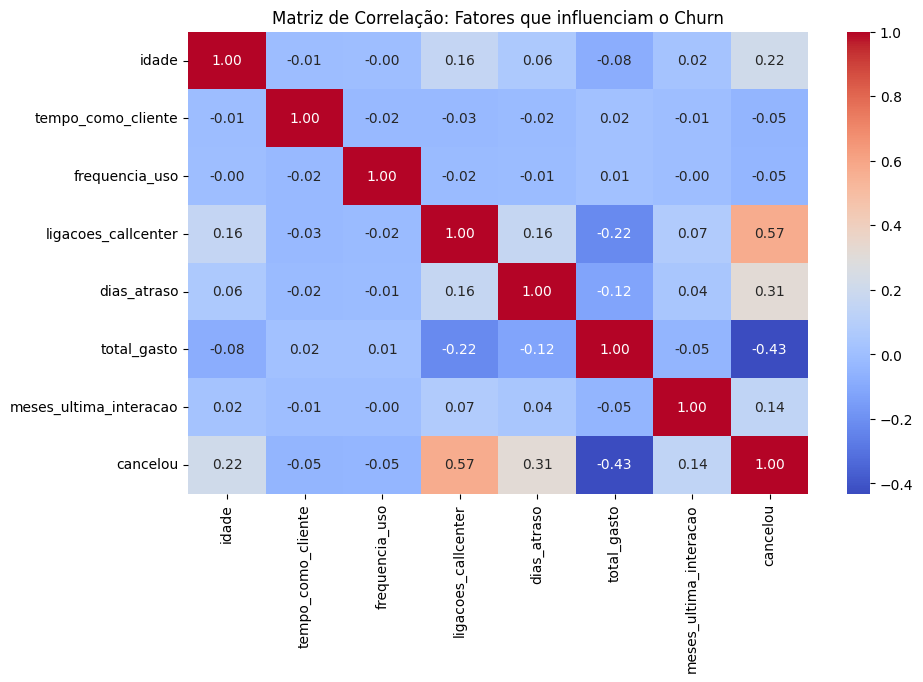

In [ ]:
# Matriz de Correlação
# Seleção de apenas as colunas numéricas para analisar a força da relação com o cancelamento
colunas_numericas = cancelamentos.select_dtypes(include=['number'])
correlacao = colunas_numericas.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação: Fatores que influenciam o Churn")
plt.show()

In [ ]:
import plotly.subplots as sp
import plotly.graph_objects as go

# Definição da função para consolidar os principais gatilhos de Churn em uma única visualização estratégica
def criar_dashboard_estilizado(df):
    fig = sp.make_subplots(
        rows=2, cols=2,
        subplot_titles=(
            "<b>Comportamento por contrato</b>",
            "<b>Frequência no Call Center</b>",
            "<b>Histórico de inadimplência</b>",
            "<b>Distribuição por plano</b>"
        ),
        vertical_spacing=0.12,
        horizontal_spacing=0.08
    )

    # Padronização das cores: Azul para clientes ativos (0), Vermelho para cancelados (1)
    cor_ativo = '#2B3467'
    cor_churn = '#EB455F'

    # Função para automatizar a inserção das barras em cada quadrante
    def adicionar_barras_ao_quadrante(coluna, linha, col, mostrar_legenda=False):
        for status, cor, nome in zip([0, 1], [cor_ativo, cor_churn], ['Ativo', 'Inativo']):
            # Filtro os dados para separar quem cancelou de quem não cancelou
            dados_filtrados = df[df['cancelou'] == status]

            # Contagem automatica para a variável escolhida
            fig.add_trace(
                go.Histogram(
                    x=dados_filtrados[coluna],
                    marker_color=cor,
                    name=nome,
                    showlegend=mostrar_legenda,
                    marker_line=dict(width=0.5, color='white')
                ),
                row=linha, col=col
            )

    # Variáveis críticas identificadas na análise
    adicionar_barras_ao_quadrante('duracao_contrato', 1, 1, mostrar_legenda=True)
    adicionar_barras_ao_quadrante('ligacoes_callcenter', 1, 2)
    adicionar_barras_ao_quadrante('dias_atraso', 2, 1)
    adicionar_barras_ao_quadrante('assinatura', 2, 2)

    # Layout
    fig.update_layout(
        height=850, width=1000,
        template="plotly_white",
        title={
            'text': "<b>ANÁLISE DE EVASÃO (CHURN)</b><br><span style='font-size:14px; color:gray'>Visualização consolidada dos gatilhos críticos de cancelamento</span>",
            'y': 0.96, 'x': 0.5, 'xanchor': 'center', 'yanchor': 'top'
        },
        barmode='group', # (tivo vs Inativo para comparação
        bargap=0.15,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )

    # Padronização dos eixos
    fig.update_yaxes(title="Qtd. Clientes", gridcolor='#F0F0F0', zeroline=False)

    fig.show()

criar_dashboard_estilizado(cancelamentos)

**Diagnóstico de Causas Raiz (Key Insights)**

A análise exploratória revelou três drivers críticos que impulsionam a alta taxa de evasão. Cada um desses pontos representa uma oportunidade de intervenção direta para a recuperação da base:

**1. Fragilidade do Modelo de Retenção (Ciclo de Contrato)**
*   Diagnóstico: Foi identificado que 100% dos clientes no modelo de contrato mensal (Monthly) cancelaram o serviço.
*   Impacto de Negócio: O modelo mensal não estabelece uma barreira de saída nem permite o tempo de maturação necessário para o cliente perceber o valor do produto (Time-to-Value).

**2. Gatilho de Insatisfação no Atendimento (Atrito)**
*   Diagnóstico: Existe um ponto de ruptura estatística no Call Center. Clientes que atingem a 5ª ligação apresentam uma probabilidade de churn drasticamente superior.
*   Impacto de Negócio: O excesso de interações é um sintoma de falha no First Call Resolution (Resolução no Primeiro Contato), transformando o suporte em um canal de frustração, não de solução.

**3. Indicador Financeiro Antecedente (Inadimplência)**

*   Diagnóstico: Atrasos superiores a 20 dias atuam como o principal preditor de cancelamento.
*   Impacto de Negócio: Após o marco de 20 dias, o engajamento cai a níveis quase irreversíveis, sinalizando que as réguas de cobrança e recuperação atuais estão sendo acionadas tardiamente.






# **Simulação de Impacto Estratégico (Análise Contrafactual)**



Após diagnosticar os três principais drivers de cancelamento, será realizado uma simulação para quantificar o impacto financeiro e operacional caso a empresa implemente ações corretivas focadas em:

*   Migração de Contratos: Desincentivar o modelo mensal.
*   Eficiência no Atendimento: Limitar o atrito a no máximo 4 ligações (resolução rápida).
*   Gestão Financeira: Resolver pendências antes dos 20 dias de atraso.

In [ ]:
import plotly.graph_objects as go

# --- CÁLCULO DA MÉTRICA ATUAL (BASELINE) ---
# Como a coluna 'cancelou' contém 0 e 1, a média .mean()) calcula automaticamente a proporção de cancelamentos na base total.
churn_atual = cancelamentos["cancelou"].mean()

# --- FILTRO CONTRAFACTUAL (CENÁRIO "E SE?") ---
# Criação de uma base otimizada removendo os 'drivers de risco' identificados na EDA:
# Remoção de 'Monthly' (Contratos mensais que geram evasão imediata)
# Limitação das'ligacoes_callcenter' a 4 (Ponto de ruptura do suporte)
# Limitação dos 'dias_atraso' a 20 (Marco crítico de inadimplência)
base_otimizada = cancelamentos.query("duracao_contrato != 'Monthly' and ligacoes_callcenter <= 4 and dias_atraso <= 20")

# --- CÁLCULO DA MÉTRICA PROJETADA (CHURN RESIDUAL) ---
# Calculo da média de cancelamento apenas sobre os clientes que restaram, mostra qual seria o Churn se os problemas acima fossem resolvidos.
churn_projetado = base_otimizada["cancelou"].mean()

# --- OUTPUT EXECUTIVO ---
print(f"{' RELATÓRIO DE IMPACTO ESTRATÉGICO ':=^50}")
print(f"Taxa de Churn Atual:       {churn_atual:>10.1%}")
print(f"Taxa de Churn Projetada:   {churn_projetado:>10.1%}")
print(f"Redução Potencial:         {(churn_atual - churn_projetado):>10.1%}")
print(f"{'='*50}")

# --- VISUALIZAÇÃO ---
fig = go.Figure()

# Barra de Churn Atual
fig.add_trace(go.Bar(
    x=['Situação Atual (Baseline)'],
    y=[churn_atual * 100],
    name='Churn Atual',
    marker_color='#EB455F', # Vermelho
    text=[f"{churn_atual:.1%}"],
    textposition='auto',
    marker_line=dict(color='#2B3467', width=1.5)
))

# Barra de Churn Projetado
fig.add_trace(go.Bar(
    x=['Cenário Pós-Ações'],
    y=[churn_projetado * 100],
    name='Churn Projetado',
    marker_color='#2eb872', # Verde Profissional
    text=[f"{churn_projetado:.1%}"],
    textposition='auto',
    marker_line=dict(color='#2B3467', width=1.5)
))

# Layout
fig.update_layout(
    title={
        'text': "<b>Simulação de Impacto: Plano de Retenção Estratégica</b><br><span style='font-size:14px'>Redução potencial de churn ao mitigar gatilhos de atrito</span>",
        'y':0.9, 'x':0.5, 'xanchor': 'center', 'yanchor': 'top'
    },
    plot_bgcolor='white', # Fundo limpo
    paper_bgcolor='white',
    showlegend=False,
    bargap=0.4,
    yaxis=dict(
        title="Taxa de Cancelamento (%)",
        ticksuffix="%",
        range=[0, 100],
        gridcolor='#F0F0F0' # Grades sutis
    ),
    font=dict(family="Arial, sans-serif", size=14, color="#2B3467")
)

# Anotação de destaque com a redução total
reducao = (churn_atual - churn_projetado)
fig.add_annotation(
    x=0.5, y=churn_atual*100 + 10,
    text=f"<b>Redução Estimada: -{reducao:.1%}</b>",
    showarrow=False,
    font=dict(size=16, color="#2B3467"),
    bgcolor="#FCFFE7",
    bordercolor="#2B3467",
    borderwidth=2,
    borderpad=4
)

fig.show()

======== RELATÓRIO DE IMPACTO ESTRATÉGICO ========
Taxa de Churn Atual:            56.8%
Taxa de Churn Projetada:        18.4%
Redução Potencial:              38.4%


# **Valor de Negócio Gerado**

A análise técnica demonstrou que a alta taxa de cancelamento (56%) não é um comportamento aleatório, mas sim o resultado de gatilhos operacionais específicos. Através da simulação estatística, provamos que a mitigação desses pontos de atrito pode elevar a retenção da base para 82% (reduzindo o churn para 18%).

**Plano de ação recomendado**

Para atingir os resultados projetados, as seguintes medidas estratégicas devem ser implementadas:

Revisão do Mix de Contratos:

1. Revisão do Mix de Contratos:
* Ação: Desincentivar o plano mensal através de precificação premium e oferecer descontos agressivos para a migração para os planos anuais.
* Objetivo: Aumentar o Lifetime Value (LTV) e criar barreiras de saída saudáveis.

2. Otimização do First Call Resolution (FCR):
* Ação: Implementar um gatilho de prioridade no CRM para clientes que atingirem a 3ª ligação de suporte no mês.
* Objetivo: Resolver o problema do cliente antes que ele atinja o marco crítico de 5 ligações, onde a probabilidade de churn se torna irreversível.

3. Régua de Cobrança Antecipada:
* Ação: Automatizar notificações de pagamento via múltiplos canais (SMS, E-mail, WhatsApp) logo após o 5º dia de atraso.
* Objetivo: Evitar que a inadimplência ultrapasse o limite de 20 dias, ponto em que o engajamento do cliente é perdido.

**Este projeto fornece à diretoria um mapa de prioridades baseado em dados. Com foco direcionado a 3 drivers especificos, que possuem o maior potencial de retorno sobre o investimento (ROI).**
